# Handwritten digit classification

## Import Libraries

In [65]:
import numpy as np
import cv2 as cv
from scipy.io import loadmat
from tensorflow import keras
from keras.layers import Dense
from keras.models import Sequential
from sklearn.model_selection import train_test_split

## Load the Dataset

In [66]:
dataset = loadmat("Dataset/Data_hoda_full.mat")

X = dataset["Data"][:2500]
y = dataset["labels"][:2500]

X = np.squeeze(X)
y = np.squeeze(y)

## Split the Dataset into Training and Testing Sets

In [67]:
X_train, X_test, y_train_orginal, y_test_orginal = train_test_split(
    X, y, random_state=42, test_size=.2
)

y_train = keras.utils.to_categorical(y_train_orginal, num_classes=10)
y_test = keras.utils.to_categorical(y_test_orginal, num_classes=10)

X_train = [cv.resize(img, (5, 5)) for img in X_train]
X_test = [cv.resize(img, (5, 5)) for img in X_test]

X_train = np.reshape(X_train, (-1, 25)).astype("float32")
X_test = np.reshape(X_test, (-1, 25)).astype('float32')

X_train /= 255
X_test /= 255

## Build the Neural Network Architecture

In [68]:
model = Sequential()
model.add(Dense(64, activation="relu", input_dim=25))
model.add(Dense(32, activation="relu"))
model.add(Dense(16, activation="relu"))
model.add(Dense(10, activation="softmax"))
model.summary()

model.compile(optimizer="rmsprop", loss="categorical_crossentropy", metrics=['accuracy'])
model.fit(X_train, y_train, batch_size=64, epochs=100, validation_split=.2)

c:\Users\Amirkr\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_35 (Dense)                │ (None, 64)             │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 10)             │           170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,442 (17.35 KB)

 Trainable params: 4,442 (17.35 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.2475 - loss: 2.1443 - val_accuracy: 0.3650 - val_loss: 1.9554
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4613 - loss: 1.8098 - val_accuracy: 0.5125 - val_loss: 1.6046
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5956 - loss: 1.4632 - val_accuracy: 0.6725 - val_loss: 1.2623
Epoch 4/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7081 - loss: 1.1510 - val_accuracy: 0.8000 - val_loss: 0.9741
Epoch 5/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7981 - loss: 0.8990 - val_accuracy: 0.8300 - val_loss: 0.7642
Epoch 6/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8081 - loss: 0.7250 - val_accuracy: 0.8450 - val_loss: 0.6203
Epoch 7/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8300 - loss: 0.6109 - val_accuracy: 0.8400 - val_loss: 0.5358
Epoch 8/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8444 - loss: 0.5301 - val_accuracy: 0.8650 - v

## Evaluate the Model on the Test Set

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9020 - loss: 0.3444 
loss: 0.3443935811519623, acc: 90.20%
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


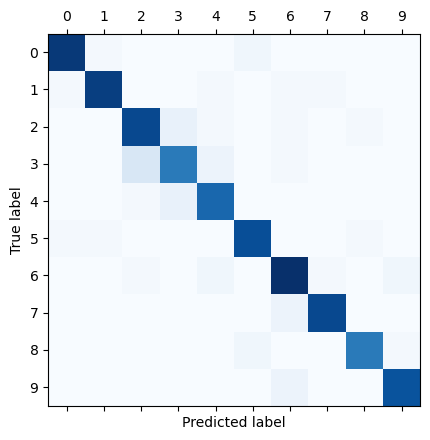

Exception in callback BaseSelectorEventLoop._read_from_self()
handle: <Handle BaseSelectorEventLoop._read_from_self()>
Traceback (most recent call last):
  File "c:\Users\Amirkr\anaconda3\Lib\asyncio\events.py", line 89, in _run
    self._context.run(self._callback, *self._args)
    ~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Amirkr\anaconda3\Lib\asyncio\selector_events.py", line 132, in _read_from_self
    data = self._ssock.recv(4096)
ConnectionResetError: [WinError 10054] An existing connection was forcibly closed by the remote host
Exception in callback BaseSelectorEventLoop._read_from_self()
handle: <Handle BaseSelectorEventLoop._read_from_self()>
Traceback (most recent call last):
  File "c:\Users\Amirkr\anaconda3\Lib\asyncio\events.py", line 89, in _run
    self._context.run(self._callback, *self._args)
    ~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Amirkr\anaconda3\Lib\asyncio\selector_events.py", line 132, in _read_from_self
    data = 

In [ ]:
loss, acc = model.evaluate(X_test, y_test)
print(f"loss: {loss}, acc: {acc*100:.2f}%")

predicted = model.predict(X_test)
predicted_classes = np.argmax(predicted, axis=1)

# Generate the Confusion Matrix

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

plt.matshow(confusion_matrix(y_test_orginal, predicted_classes), cmap="Blues")
plt.xticks(range(10))
plt.yticks(range(10))
plt.xlabel("Predicted label")
plt.ylabel("True label");